In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
import pickle
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
import random
from datetime import datetime

%matplotlib inline
print('All imports done')

All imports done


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────
data_dir  = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")

# classes sorted — matches ImageFolder alphabetical order
classes = sorted(os.listdir(train_dir))

plants           = []
NumberOfDiseases = 0
for plant in classes:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

print(f"Total classes   : {len(classes)}")
print(f"Unique plants   : {len(plants)}")
print(f"Unique diseases : {NumberOfDiseases}")

Total classes   : 38
Unique plants   : 14
Unique diseases : 26


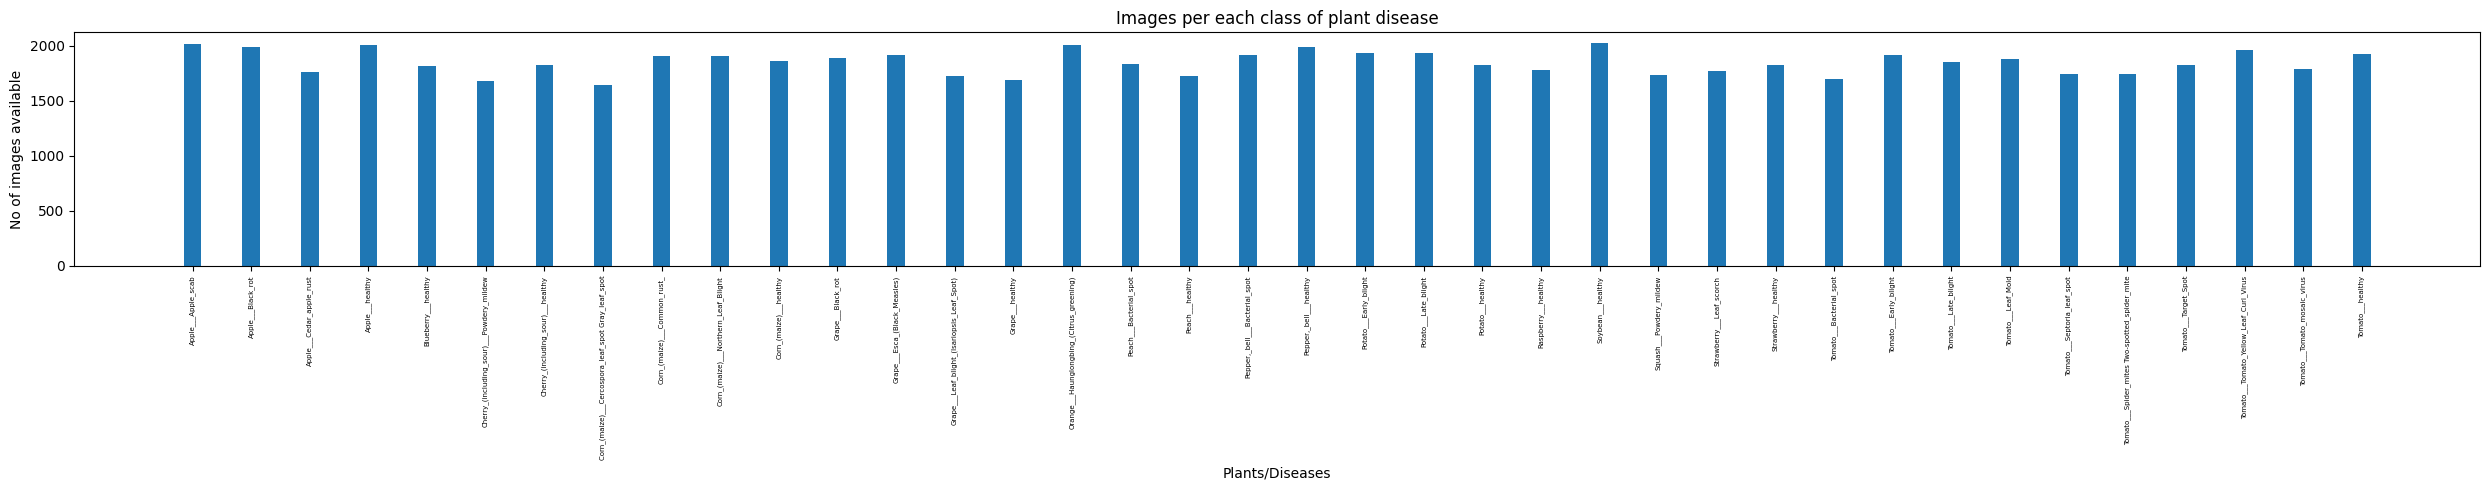

There are 70295 images for training


In [3]:
# ── Cell 3: EDA ───────────────────────────────────────────────────
nums = {}
for disease in classes:
    nums[disease] = len(os.listdir(os.path.join(train_dir, disease)))

img_per_class = pd.DataFrame(
    nums.values(), index=nums.keys(), columns=["no. of images"]
)

index = list(range(len(classes)))
plt.figure(figsize=(25, 5))
plt.bar(index, list(nums.values()), width=0.3)
plt.xlabel('Plants/Diseases', fontsize=10)
plt.ylabel('No of images available', fontsize=10)
plt.xticks(index, classes, fontsize=5, rotation=90)
plt.title('Images per each class of plant disease')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

n_train = sum(nums.values())
print(f"There are {n_train} images for training")

In [4]:
# ── Cell 4: Transforms ────────────────────────────────────────────
# Training: small rotation — GOAD uses larger rotations internally
train_transform = transforms.Compose([
    transforms.Resize((236, 236)),                  # small upscale buffer
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),                  # slightly higher OK for ConvNeXt
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
_norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

GOAD_TRANSFORMS = [
    transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomRotation((90,90)), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomRotation((180,180)), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomRotation((270,270)), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), _norm]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomRotation((90,90)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), _norm]),
]

M = len(GOAD_TRANSFORMS)
print(f"GOAD: M = {M} geometric transformations")

GOAD: M = 8 geometric transformations


In [6]:
# ── Cell 5: Datasets ──────────────────────────────────────────────
train = ImageFolder(train_dir, transform=train_transform)
valid = ImageFolder(valid_dir, transform=valid_transform)

# classes extracted directly from dataset — no hardcoding
CLASSES     = train.classes
NUM_CLASSES = len(CLASSES)

print(f"Train   : {len(train)} images")
print(f"Valid   : {len(valid)} images")
print(f"Classes : {NUM_CLASSES}")

img, label = train[0]
print(f"Image shape: {img.shape} | Label: {label} → {CLASSES[label]}")

Train   : 70295 images
Valid   : 17572 images
Classes : 38
Image shape: torch.Size([3, 224, 224]) | Label: 0 → Apple___Apple_scab


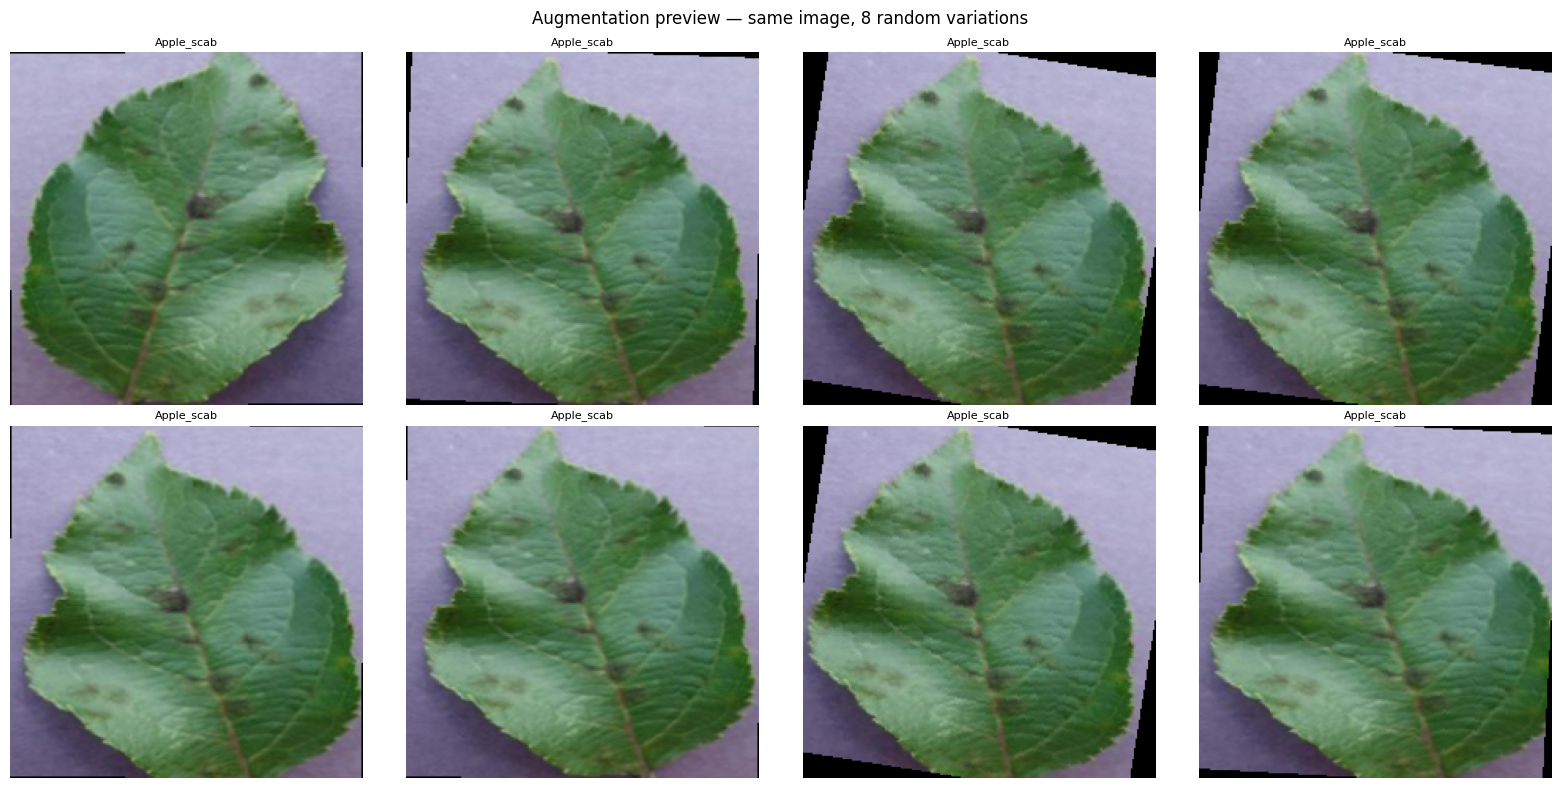

In [7]:
# ── Cell 6: Augmentation preview ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img, label = train[0]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = torch.clamp(img * std + mean, 0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[label].split('___')[1][:20], fontsize=8)
    ax.axis('off')
plt.suptitle('Augmentation preview — same image, 8 random variations')
plt.tight_layout()
plt.show()

In [8]:
# ── Cell 7: DataLoaders + GPU helpers ─────────────────────────────
random_seed = 7
torch.manual_seed(random_seed)
batch_size = 32

train_dl = DataLoader(train, batch_size, shuffle=True,  num_workers=2, pin_memory=True)
valid_dl = DataLoader(valid, batch_size,                num_workers=2, pin_memory=True)

def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl     = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
        return len(self.dl)

device   = get_default_device()
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)
print(f'Device: {device}')

Device: cuda


In [9]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return (preds == labels).float().mean()

class ImageClassificationBase(nn.Module):

    def training_step(self, batch):
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        out  = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc  = accuracy(out, labels)

        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses   = [x['val_loss'] for x in outputs]
        batch_accuracy = [x['val_acc']  for x in outputs]

        epoch_loss     = torch.stack(batch_losses).mean()
        epoch_accuracy = torch.stack(batch_accuracy).mean()

        return {'val_loss': epoch_loss, 'val_accuracy': epoch_accuracy}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'],
            result['val_loss'], result['val_accuracy']))

In [10]:
# ── Cell 9: ConvNeXt-Tiny with feature extraction ────────────────

class ConvNeXtTiny(ImageClassificationBase):
    def __init__(self, num_classes):
        super().__init__()
        self.network = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        # Get input features of classifier
        in_features = self.network.classifier[2].in_features

        # Replace classifier (same idea as yours)
        self.network.classifier = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, xb):
        features = self.network.features(xb)
        features = self.network.avgpool(features)
        features = torch.flatten(features, 1)
    
        logits = self.network.classifier(features)
        return logits   

    def extract_features(self, xb):
        features = self.network.features(xb)
        features = self.network.avgpool(features)
        features = torch.flatten(features, 1)
    
        logits = self.network.classifier(features)
        return features, logits

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvNeXtTiny(NUM_CLASSES)
model = model.to(device)

print("Model created successfully ✅")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 197MB/s] 


Model created successfully ✅


In [12]:
# ── Cell 11: Training utilities ───────────────────────────────────
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']


def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader,
                 weight_decay=1e-4, grad_clip=None,
                 opt_func=torch.optim.AdamW):   # ✅ AdamW by default

    torch.cuda.empty_cache()
    history = []

    # ✅ Proper optimizer init for AdamW / ConvNeXt
    optimizer = opt_func(model.parameters(), lr=max_lr, weight_decay=weight_decay)

    # ✅ OneCycleLR (works well with ConvNeXt if LR is reasonable)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader)
    )

    for epoch in range(epochs):
        model.train()
        train_losses = []
        lrs = []

        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)

            loss.backward()

            # ✅ optional gradient clipping
            if grad_clip:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            lrs.append(get_lr(optimizer))
            sched.step()

        # ✅ validation
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs

        model.epoch_end(epoch, result)
        history.append(result)

    return history

In [13]:
train_dl = DataLoader(train, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dl = DataLoader(valid, batch_size, num_workers=2, pin_memory=True)

In [14]:
%%time
history = [evaluate(model, valid_dl)]
print(history)

[{'val_loss': tensor(3.8122, device='cuda:0'), 'val_accuracy': tensor(0.0376, device='cuda:0')}]
CPU times: user 33.1 s, sys: 3.07 s, total: 36.2 s
Wall time: 1min 43s


In [15]:
epochs       = 10
max_lr       = 2e-4          
grad_clip    = 1.0           
weight_decay = 1e-4
opt_func     = torch.optim.AdamW   

In [16]:
%%time
history += fit_OneCycle(
    epochs,
    max_lr,
    model,
    train_dl,
    valid_dl,
    grad_clip=grad_clip,
    weight_decay=weight_decay,
    opt_func=opt_func
)


Epoch [0], last_lr: 0.00006, train_loss: 0.6500, val_loss: 0.0408, val_acc: 0.9870
Epoch [1], last_lr: 0.00015, train_loss: 0.0444, val_loss: 0.0380, val_acc: 0.9893
Epoch [2], last_lr: 0.00020, train_loss: 0.0552, val_loss: 0.0763, val_acc: 0.9799
Epoch [3], last_lr: 0.00019, train_loss: 0.0419, val_loss: 0.0240, val_acc: 0.9936
Epoch [4], last_lr: 0.00016, train_loss: 0.0264, val_loss: 0.0610, val_acc: 0.9860
Epoch [5], last_lr: 0.00012, train_loss: 0.0167, val_loss: 0.0200, val_acc: 0.9951
Epoch [6], last_lr: 0.00008, train_loss: 0.0068, val_loss: 0.0076, val_acc: 0.9982
Epoch [7], last_lr: 0.00004, train_loss: 0.0030, val_loss: 0.0036, val_acc: 0.9992
Epoch [8], last_lr: 0.00001, train_loss: 0.0007, val_loss: 0.0046, val_acc: 0.9990
Epoch [9], last_lr: 0.00000, train_loss: 0.0003, val_loss: 0.0026, val_acc: 0.9994
CPU times: user 2h 50min 56s, sys: 37min 59s, total: 3h 28min 55s
Wall time: 3h 25min 3s


In [17]:
torch.save(model.state_dict(), 'convnext_tiny_weights.pth')   
torch.save(model,              'convnext_tiny_full.pth')

print('Model saved!')

Model saved!


---
## **Evaluation & Metrics** 


In [18]:
all_preds  = []
all_labels = []

model.eval()
model = model.to(device)

with torch.no_grad():
    for images, labels in valid_dl:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Collected {len(all_preds)} predictions')

Collected 17572 predictions


In [19]:
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels,   all_preds, average='weighted')
f1        = f1_score(all_labels,       all_preds, average='weighted')

print('=' * 48)
print(f'  Weighted Precision : {precision*100:.2f}%')
print(f'  Weighted Recall    : {recall*100:.2f}%')
print(f'  Weighted F1-score  : {f1*100:.2f}%')
print('=' * 48)

short_names = [c.split('___')[1][:22] for c in CLASSES]
print(classification_report(
    all_labels, all_preds,
    target_names=short_names, digits=4
))

  Weighted Precision : 99.94%
  Weighted Recall    : 99.94%
  Weighted F1-score  : 99.94%
                        precision    recall  f1-score   support

            Apple_scab     1.0000    1.0000    1.0000       504
             Black_rot     1.0000    1.0000    1.0000       497
      Cedar_apple_rust     1.0000    1.0000    1.0000       440
               healthy     1.0000    1.0000    1.0000       502
               healthy     1.0000    1.0000    1.0000       454
        Powdery_mildew     1.0000    1.0000    1.0000       421
               healthy     1.0000    1.0000    1.0000       456
Cercospora_leaf_spot G     1.0000    0.9976    0.9988       410
          Common_rust_     0.9979    1.0000    0.9990       477
  Northern_Leaf_Blight     0.9979    0.9979    0.9979       477
               healthy     1.0000    1.0000    1.0000       465
             Black_rot     1.0000    1.0000    1.0000       472
  Esca_(Black_Measles)     1.0000    1.0000    1.0000       480
Leaf_blight_(

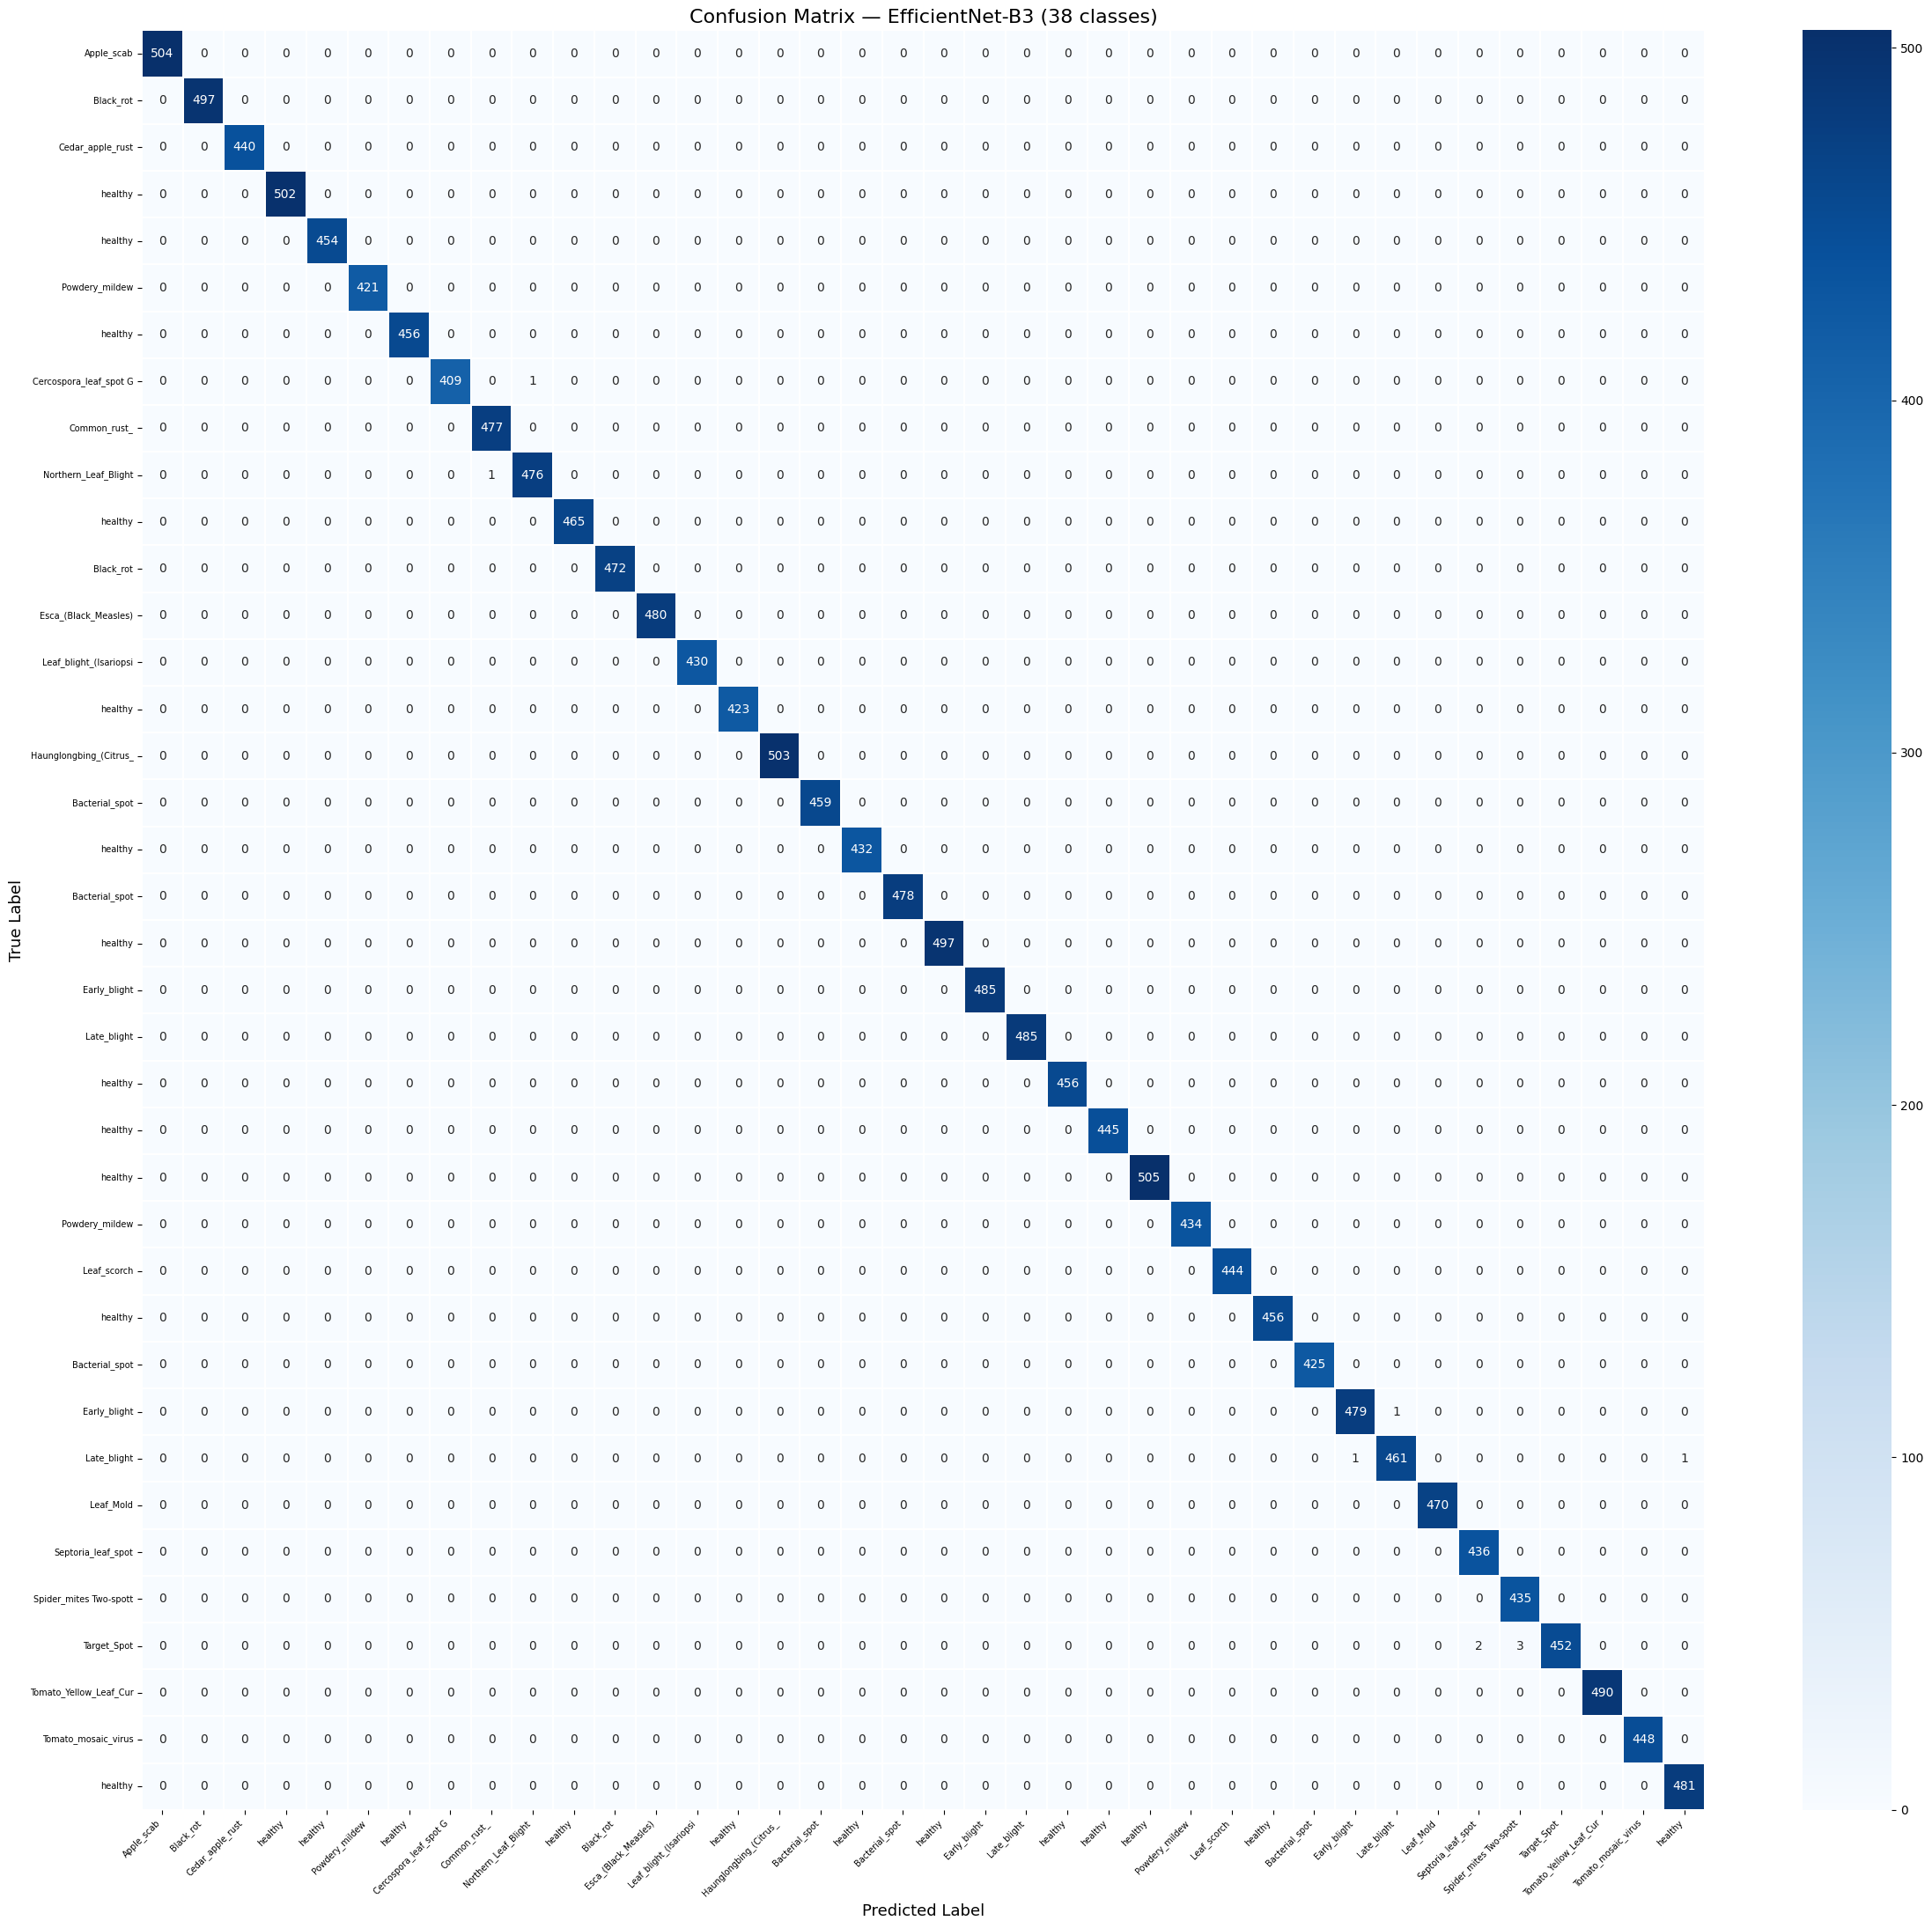

In [20]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label',      fontsize=13)
ax.set_title(f'Confusion Matrix — EfficientNet-B3 ({NUM_CLASSES} classes)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

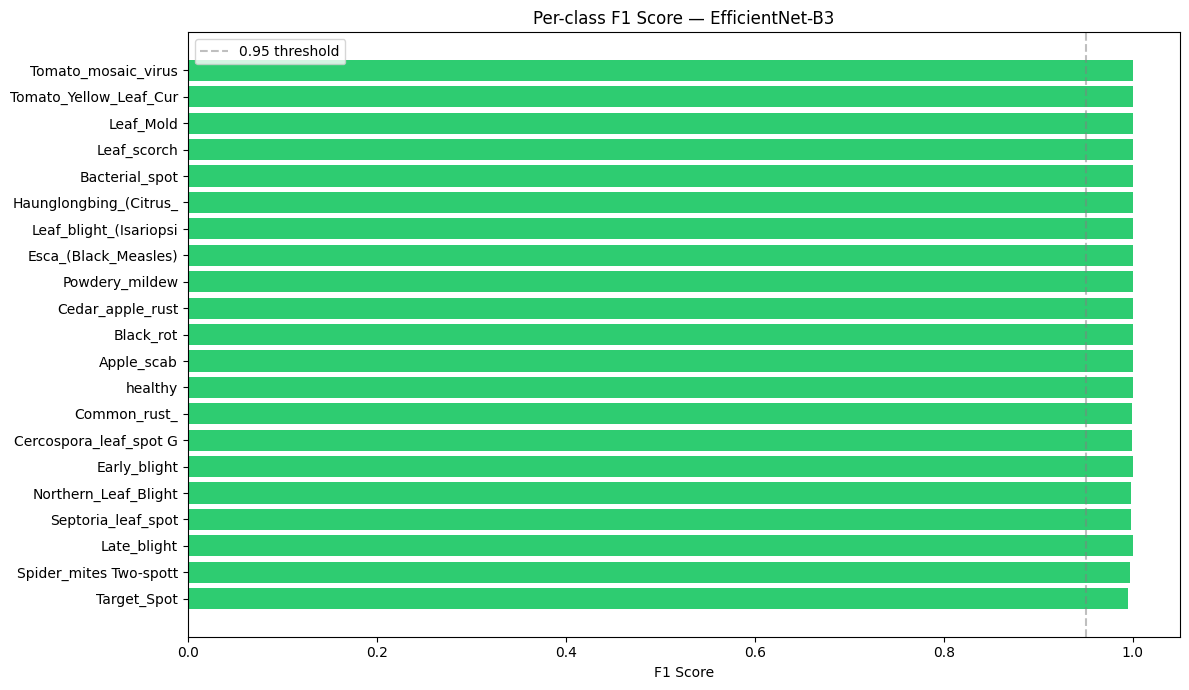

5 hardest classes:
  Target_Spot                    F1 = 0.9945
  Spider_mites Two-spott         F1 = 0.9966
  Late_blight                    F1 = 0.9968
  Septoria_leaf_spot             F1 = 0.9977
  Northern_Leaf_Blight           F1 = 0.9979

5 easiest classes:
  healthy                        F1 = 1.0000
  Bacterial_spot                 F1 = 1.0000
  Leaf_Mold                      F1 = 1.0000
  Tomato_Yellow_Leaf_Cur         F1 = 1.0000
  Tomato_mosaic_virus            F1 = 1.0000


In [21]:
per_class_f1 = f1_score(all_labels, all_preds, average=None)
f1_pairs     = sorted(zip(short_names, per_class_f1), key=lambda x: x[1])

names_sorted  = [p[0] for p in f1_pairs]
scores_sorted = [p[1] for p in f1_pairs]
colors        = ['#e74c3c' if s < 0.95 else '#2ecc71' for s in scores_sorted]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(names_sorted, scores_sorted, color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-class F1 Score — EfficientNet-B3')
ax.axvline(x=0.95, color='gray', linestyle='--', alpha=0.5, label='0.95 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

print('5 hardest classes:')
for name, score in f1_pairs[:5]:
    print(f'  {name:<30} F1 = {score:.4f}')
print('\n5 easiest classes:')
for name, score in f1_pairs[-5:]:
    print(f'  {name:<30} F1 = {score:.4f}')

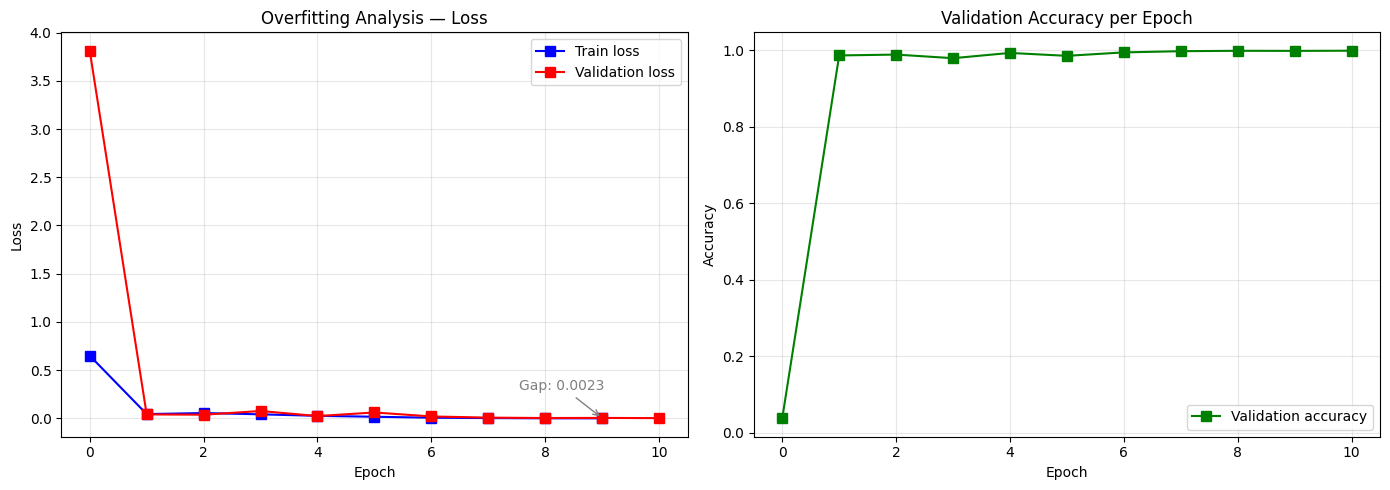

Final train loss : 0.0003
Final val loss   : 0.0026
Loss gap         : 0.0023
→ No significant overfitting.


In [22]:
# ── Cell 19: Overfitting analysis ────────────────────────────────
train_losses = [x.get('train_loss') for x in history if x.get('train_loss')]
val_losses   = [
    x['val_loss'].item() if torch.is_tensor(x['val_loss'])
    else x['val_loss'] for x in history
]
val_accs     = [
    x['val_accuracy'].item() if torch.is_tensor(x['val_accuracy'])
    else x['val_accuracy'] for x in history
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_losses, '-bs', markersize=7, label='Train loss')
ax1.plot(val_losses,   '-rs', markersize=7, label='Validation loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Overfitting Analysis — Loss')
ax1.legend()
ax1.grid(alpha=0.3)

gap = abs(train_losses[-1] - val_losses[-1])
ax1.annotate(
    f'Gap: {gap:.4f}',
    xy=(len(train_losses)-1, val_losses[-1]),
    xytext=(-60, 20), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=10, color='gray'
)

# Accuracy curve
ax2.plot(val_accs, '-gs', markersize=7, label='Validation accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy per Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Final train loss : {train_losses[-1]:.4f}')
print(f'Final val loss   : {val_losses[-1]:.4f}')
print(f'Loss gap         : {gap:.4f}')
print('→', 'No significant overfitting.' if gap < 0.1 else 'Possible overfitting — consider more regularization.')

---
## **Anomaly Detection — MSP + GOAD (Mahalanobis Distance)**
Based on: Bergman & Hoshen, ICLR 2020

In [23]:
print('Extracting validation features for GOAD covariance...')

all_val_features = []
model.eval()
model = model.to(device)

with torch.no_grad():
    for images, _ in valid_dl:
        images = images.to(device)

        feats, _ = model.extract_features(images)

        # ✅ Normalize features (CRITICAL for ConvNeXt)
        feats = torch.nn.functional.normalize(feats, p=2, dim=1)

        all_val_features.append(feats.cpu())

# Convert to numpy
all_val_features = torch.cat(all_val_features, dim=0).numpy()
print(f'Feature matrix shape: {all_val_features.shape}')


# ── Compute covariance ───────────────────────────────────────────
print('Computing shared covariance matrix...')

# ✅ Compute covariance
shared_cov = np.cov(all_val_features.T)

# ✅ Regularization (VERY IMPORTANT)
epsilon = 1e-5
shared_cov += epsilon * np.eye(shared_cov.shape[0])

# ✅ Stable inverse
cov_inv = np.linalg.pinv(shared_cov)

print(f'Covariance: {shared_cov.shape} | Inverse computed ✓')

Extracting validation features for GOAD covariance...
Feature matrix shape: (17572, 768)
Computing shared covariance matrix...
Covariance: (768, 768) | Inverse computed ✓


Computing MSP scores on validation set...
MSP Mean: 0.9998
MSP Std : 0.0055
Threshold (5%) : 1.0000
Threshold (1%) : 0.9999
✅ Selected threshold: 1.0000


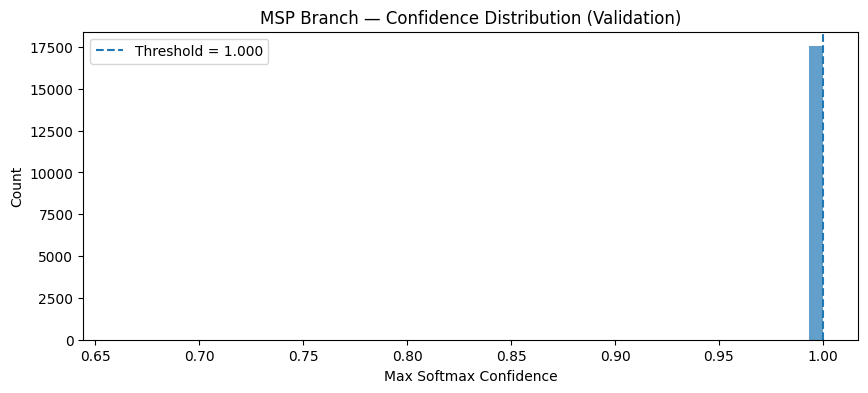

In [24]:
# ── Cell 21: MSP branch — threshold ──────────────────────────────
print('Computing MSP scores on validation set...')

msp_scores = []
model.eval()

with torch.no_grad():
    for images, _ in valid_dl:
        images = images.to(device)

        _, logits = model.extract_features(images)

        # ✅ Stable softmax
        probs = torch.softmax(logits, dim=1)
        max_conf, _ = torch.max(probs, dim=1)

        msp_scores.extend(max_conf.cpu().numpy())

msp_scores = np.array(msp_scores)

# ── Thresholds ───────────────────────────────────────────────────
msp_threshold_5 = np.percentile(msp_scores, 5)
msp_threshold_1 = np.percentile(msp_scores, 1)

# ✅ Choose ONE threshold (recommended: 5%)
msp_threshold = msp_threshold_5

print(f'MSP Mean: {msp_scores.mean():.4f}')
print(f'MSP Std : {msp_scores.std():.4f}')
print(f'Threshold (5%) : {msp_threshold_5:.4f}')
print(f'Threshold (1%) : {msp_threshold_1:.4f}')
print(f'✅ Selected threshold: {msp_threshold:.4f}')


# ── Visualization ────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(msp_scores, bins=50, alpha=0.7)

plt.axvline(msp_threshold, linestyle='--',
            label=f'Threshold = {msp_threshold:.3f}')

plt.xlabel('Max Softmax Confidence')
plt.ylabel('Count')
plt.title('MSP Branch — Confidence Distribution (Validation)')
plt.legend()

plt.savefig('msp_distribution.png', dpi=120)
plt.show()

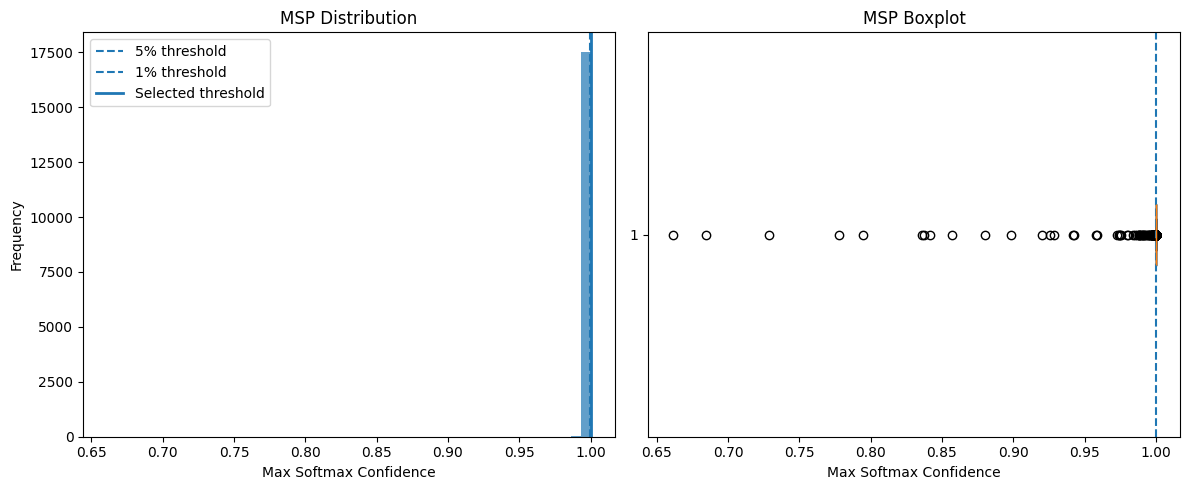

In [25]:
plt.figure(figsize=(12,5))

# ── Histogram ────────────────────────────────────────────────────
plt.subplot(1,2,1)
plt.hist(msp_scores, bins=50, alpha=0.7)

plt.axvline(msp_threshold_5, linestyle='--', label='5% threshold')
plt.axvline(msp_threshold_1, linestyle='--', label='1% threshold')

# ✅ Highlight selected threshold
plt.axvline(msp_threshold, linestyle='-', linewidth=2,
            label='Selected threshold')

plt.xlabel("Max Softmax Confidence")
plt.ylabel("Frequency")
plt.title("MSP Distribution")
plt.legend()


# ── Boxplot ──────────────────────────────────────────────────────
plt.subplot(1,2,2)
plt.boxplot(msp_scores, vert=False)

# ✅ Add threshold marker
plt.axvline(msp_threshold, linestyle='--')

plt.xlabel("Max Softmax Confidence")
plt.title("MSP Boxplot")


plt.tight_layout()
plt.show()

In [26]:
# ── Cell 22: GOAD cluster centers ────────────────────────────────

print(f'Computing GOAD cluster centers — M={M} transforms...')

valid_files = []
for cls_folder in sorted(os.listdir(valid_dir)):
    cls_path = os.path.join(valid_dir, cls_folder)
    if os.path.isdir(cls_path):
        for fname in sorted(os.listdir(cls_path)):
            valid_files.append(os.path.join(cls_path, fname))

print(f'Validation images: {len(valid_files)}')

cluster_centers = {}
BATCH_SZ        = 64
model.eval()

import torch.nn.functional as F   # ✅ needed

for m_idx, t in enumerate(GOAD_TRANSFORMS):
    m_features = []
    batch_imgs = []

    for i, fpath in enumerate(valid_files):
        try:
            img = Image.open(fpath).convert('RGB')
            batch_imgs.append(t(img))
        except:
            continue

        if len(batch_imgs) == BATCH_SZ or i == len(valid_files) - 1:
            if not batch_imgs:
                continue

            batch_t = torch.stack(batch_imgs).to(device)

            with torch.no_grad():
                feats, _ = model.extract_features(batch_t)

                # ✅ CRITICAL FIX: normalize features
                feats = F.normalize(feats, p=2, dim=1)

            m_features.append(feats.cpu())
            batch_imgs = []

    all_feats = torch.cat(m_features, dim=0).numpy()   # (N, 768)
    cluster_centers[m_idx] = all_feats.mean(axis=0)

    print(f'  T{m_idx+1}/{M} done')

print('All cluster centers computed!')

Computing GOAD cluster centers — M=8 transforms...
Validation images: 17572
  T1/8 done
  T2/8 done
  T3/8 done
  T4/8 done
  T5/8 done
  T6/8 done
  T7/8 done
  T8/8 done
All cluster centers computed!


In [27]:
# ── Cell 23: GOAD score function (Mahalanobis distance) ───────────
# Implements Paper Equations 4 + 5
# Key difference from L2: Mahalanobis accounts for feature correlations
# using the inverse covariance matrix — more sensitive to anomalies
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

EPSILON = 1e-6   # ✅ fixed

def goad_score_fast(pil_image):
    log_probs = []

    for m_idx, t in enumerate(GOAD_TRANSFORMS):

        tensor = t(pil_image).unsqueeze(0).to(device)

        with torch.no_grad():
            feat, _ = model.extract_features(tensor)

            # ✅ CRITICAL: normalize features
            feat = F.normalize(feat, p=2, dim=1)

        feat = feat[0].cpu().numpy()

        # Mahalanobis
        diffs = feat - cluster_array
        temp  = diffs @ cov_inv
        mahal = np.sum(temp * diffs, axis=1)

        # Stable softmax-like computation
        neg_d = -mahal
        exp_d = np.exp(np.clip(neg_d - np.max(neg_d), -50, 50))

        numer = exp_d[m_idx] + EPSILON
        denom = exp_d.sum() + M * EPSILON

        log_probs.append(np.log(numer / denom))

    return -np.sum(log_probs)


# ---- Sample validation images ----
print('Computing MSP + GOAD on 2000 validation samples...')
sample_files = random.sample(valid_files, 2000)

paired_msp = []
paired_goad = []

for fpath in sample_files:
    try:
        img = Image.open(fpath).convert('RGB')

        # MSP
        tensor = INFERENCE_TRANSFORM(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _, logits = model.extract_features(tensor)

        probs = torch.softmax(logits, dim=1)
        msp = torch.max(probs).item()

        # GOAD
        goad = goad_score_fast(img)

        paired_msp.append(msp)
        paired_goad.append(goad)

    except:
        continue

paired_msp = np.array(paired_msp)
paired_goad = np.array(paired_goad)

# ---- Thresholds ----
msp_threshold_5 = np.percentile(paired_msp, 5)
goad_threshold_95 = np.percentile(paired_goad, 95)

print(f"MSP → mean: {paired_msp.mean():.4f}, std: {paired_msp.std():.4f}")
print(f"GOAD → mean: {paired_goad.mean():.4f}, std: {paired_goad.std():.4f}")
print(f"MSP threshold (5%): {msp_threshold_5:.4f}")
print(f"GOAD threshold (95%): {goad_threshold_95:.4f}")

# ---- Plot 1: GOAD Distribution ----
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(paired_goad, bins=50, density=True, alpha=0.6)
sns.kdeplot(paired_goad, fill=True)
plt.axvline(goad_threshold_95, linestyle='--', color='red', label='95% threshold')
plt.title("GOAD Distribution")
plt.legend()

plt.subplot(1,2,2)
plt.boxplot(paired_goad, vert=False)
plt.title("GOAD Boxplot")

plt.tight_layout()
plt.show()

# ---- Plot 2: MSP Distribution ----
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(paired_msp, bins=50, density=True, alpha=0.6)
sns.kdeplot(paired_msp, fill=True)
plt.axvline(msp_threshold_5, linestyle='--', color='red', label='5% threshold')
plt.title("MSP Distribution")
plt.legend()

plt.subplot(1,2,2)
plt.boxplot(paired_msp, vert=False)
plt.title("MSP Boxplot")

plt.tight_layout()
plt.show()

# ---- Plot 3: MSP vs GOAD (KEY GRAPH 🔥) ----
plt.figure(figsize=(6,5))
plt.scatter(paired_msp, paired_goad, alpha=0.3)

plt.axvline(msp_threshold_5, linestyle='--', color='red')
plt.axhline(goad_threshold_95, linestyle='--', color='blue')

plt.xlabel("MSP Confidence")
plt.ylabel("GOAD Score")
plt.title("MSP vs GOAD (Decision Space)")

plt.text(0.2, goad_threshold_95+1, "Anomaly (GOAD)", color='blue')
plt.text(msp_threshold_5+0.01, min(paired_goad), "Low MSP", color='red')

plt.show()

# ---- Sanity check ----
print("GOAD range:", paired_goad.min(), "→", paired_goad.max())

Computing MSP + GOAD on 2000 validation samples...


IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
def decision_fusion(pil_image, model, device,
                    cluster_centers, cov_inv,
                    msp_threshold, goad_threshold,
                    epsilon=EPSILON):

    model.eval()

    # ---- Preprocessing ----
    tensor = INFERENCE_TRANSFORM(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        feats, logits = model.extract_features(tensor)

        # ✅ IMPORTANT: normalize features
        feats = torch.nn.functional.normalize(feats, p=2, dim=1)

        probs = torch.softmax(logits, dim=1)[0]
        msp_conf = probs.max().item()

    # ---- MSP branch ----
    if msp_conf < msp_threshold:
        return {
            'is_anomaly': True,
            'reason': f'MSP: low confidence ({msp_conf:.3f} < {msp_threshold:.3f})',
            'msp_conf': msp_conf,
            'goad_score': None,
            'top5': None,
            'plant': None,
            'condition': None
        }

    # ---- GOAD branch ----
    g_score = goad_score_fast(
        pil_image, model, device,
        cluster_centers, cov_inv, epsilon
    )

    if g_score > goad_threshold:
        return {
            'is_anomaly': True,
            'reason': f'GOAD: unusual pattern ({g_score:.3f} > {goad_threshold:.3f})',
            'msp_conf': msp_conf,
            'goad_score': g_score,
            'top5': None,
            'plant': None,
            'condition': None
        }

    # ---- Normal classification ----
    top5p, top5i = torch.topk(probs, 5)

    top5 = []
    for p, i in zip(top5p.cpu(), top5i.cpu()):
        class_name = CLASSES[i]

        if '___' in class_name:
            plant, condition = class_name.split('___')
        else:
            plant, condition = class_name, "unknown"

        top5.append({
            'class': class_name,
            'prob': p.item(),
            'plant': plant,
            'condition': condition
        })

    return {
        'is_anomaly': False,
        'reason': '',
        'msp_conf': msp_conf,
        'goad_score': g_score,
        'top5': top5,
        'plant': top5[0]['plant'],
        'condition': top5[0]['condition']
    }

In [ ]:
test_path = random.choice(valid_files)
test_img  = Image.open(test_path).convert('RGB')

result = decision_fusion(
    test_img, model, device,
    cluster_centers, cov_inv,
    msp_threshold, goad_threshold
)

print('=' * 60)
print('🔍 Pipeline Test Result')
print('=' * 60)

msp_val  = result["msp_conf"]
goad_val = result["goad_score"]

print(f'  MSP confidence : {msp_val:.4f}  (threshold: {msp_threshold:.4f})')

if goad_val is not None:
    print(f'  GOAD score     : {goad_val:.4f}  (threshold: {goad_threshold:.4f})')
else:
    print(f'  GOAD score     : skipped (MSP rejected)')

print(f'  Anomaly        : {result["is_anomaly"]}')

if result['is_anomaly']:
    print(f'  Reason         : {result["reason"]}')
else:
    print(f'  Plant          : {result["plant"]}')
    print(f'  Condition      : {result["condition"]}')
    print('\n  Top-5 Predictions:')
    
    for i, r in enumerate(result['top5']):
        print(f'    {i+1}. {r["class"]:<45} {r["prob"]*100:.2f}%')

print('=' * 60)


# ---- Visualization ----
plt.figure(figsize=(4, 4))
plt.imshow(test_img)

if result['is_anomaly']:
    if goad_val is not None:
        title = f"🚨 ANOMALY\nMSP={msp_val:.3f} | GOAD={goad_val:.3f}"
    else:
        title = f"🚨 ANOMALY\nMSP={msp_val:.3f}"
else:
    cond = result['condition'].replace('_', ' ')
    title = f"🌿 {cond}\nMSP={msp_val:.3f} | GOAD={goad_val:.3f}"

plt.title(title)
plt.axis('off')
plt.show()

In [ ]:
# Convert cluster centers → array
cluster_array = np.stack([cluster_centers[m] for m in range(M)])

anomaly_params = {
    'version':         'v3.0',
    'timestamp':       datetime.now().strftime("%Y-%m-%d %H:%M"),

    # Core thresholds
    'msp_threshold':   float(msp_threshold),
    'goad_threshold':  float(goad_threshold),

    # GOAD parameters
    'cluster_centers': cluster_array,
    'cov_inv':         np.array(cov_inv),
    'M':               M,
    'epsilon':         EPSILON,

    # Metadata (UPDATED)
    'distance_metric': 'mahalanobis',
    'method':          'MSP + GOAD — Bergman & Hoshen ICLR 2020',
    'feature_dim':     768,                    # ✅ FIXED
    'feature_norm':    'L2',                   # ✅ IMPORTANT
    'input_size':      (3, 224, 224),         # ✅ IMPORTANT
    'model':           'ConvNeXt-Tiny',       # ✅ FIXED
    'num_classes':     NUM_CLASSES,
    'classes':         CLASSES,
}

with open('anomaly_params.pkl', 'wb') as f:
    pickle.dump(anomaly_params, f)

print('Saved: anomaly_params.pkl')


print()
print('=' * 55)
print('  FINAL RESULTS')
print('=' * 55)

final_acc = history[-1]['val_accuracy']
if torch.is_tensor(final_acc):
    final_acc = final_acc.item()

print(f'  Val Accuracy    : {final_acc*100:.2f}%')
print(f'  Weighted F1     : {f1*100:.2f}%')
print(f'  Precision       : {precision*100:.2f}%')
print(f'  Recall          : {recall*100:.2f}%')
print(f'  MSP threshold   : {msp_threshold:.4f}')
print(f'  GOAD threshold  : {goad_threshold:.4f}')
print(f'  Loss gap        : {gap:.4f} → {"No overfitting" if gap < 0.1 else "Check regularization"}')

print('=' * 55)
print('Files ready:')
print('  convnext_tiny_weights.pth')
print('  anomaly_params.pkl')
print('  confusion_matrix.png')
print('  per_class_f1.png')
print('  overfitting_analysis.png')
print('  msp_distribution.png')
print('  goad_distribution.png')